# Plot model and satellite SIC

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime
import boto3
import s3fs
import gc

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:35767")
client

<Client: 'tcp://127.0.0.1:35767' processes=8 threads=32, memory=123.95 GiB>

### Open satellite data

In [3]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

In [4]:
sic_ancillary =  xr.open_dataset(sic_files[0])

In [5]:
lat_min = 68
lat_max = 72
lon_min = -158
lon_max = -120

In [6]:
# sic_ds = xr.open_dataset(sic_files[1])
sic_ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20160915_F17_v05r00.nc')

In [7]:
sat_subset_mask = sic_ds.where(
    (sic_ancillary.latitude >= lat_min) & (sic_ancillary.latitude <= lat_max) &
    (sic_ancillary.longitude >= lon_min) & (sic_ancillary.longitude <= lon_max)
)

In [8]:
sat_beaufort_mask = ((sic_ancillary.latitude >= lat_min) & (sic_ancillary.latitude <= lat_max) &
                   (sic_ancillary.longitude >= lon_min) & (sic_ancillary.longitude <= lon_max))

In [ ]:
# --- configuration ---
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
years = range(2014, 2021)
months = range(1, 13)

# --- lists to store results ---
monthly_means = []
monthly_stds = []
monthly_times = []

# --- loop through each year and month ---
for year in years:
    for month in months:
        # find all daily files for this month
        file_pattern = os.path.join(data_dir, f"*{year}{month:02d}*.nc")
        sic_month_files = sorted(glob.glob(file_pattern))
        
        if not sic_month_files:
            print(f"No files found for {year}-{month:02d}")
            continue

        try:
            # open dataset lazily
            sic_month_tmp = xr.open_mfdataset(
                sic_month_files,
                combine='by_coords',
                chunks={'time': -1}
            )

            # apply mask and convert to %
            sic_month_beaufort = (sic_month_tmp.cdr_seaice_conc * 100).where(sat_beaufort_mask)

            # Compute daily spatial mean (averaged over x,y)
            daily_spatial_mean = sic_month_beaufort.mean(dim=("y", "x"), skipna=True)

            # Compute monthly mean and std across the daily values
            monthly_mean = daily_spatial_mean.mean(dim="time", skipna=True).compute()
            monthly_std  = daily_spatial_mean.std(dim="time", ddof=1, skipna=True).compute()

            # store results
            monthly_means.append(float(monthly_mean.values))
            monthly_stds.append(float(monthly_std.values))
            monthly_times.append(pd.Timestamp(year=year, month=month, day=15))

            print(f"Processed {year}-{month:02d}")

        except Exception as e:
            print(f"Error processing {year}-{month:02d}: {e}")

        finally:
            # --- Clean up memory ---
            try:
                sic_month_tmp.close()
            except:
                pass
            del sic_month_tmp, sic_month_beaufort, daily_spatial_mean
            gc.collect()

In [66]:
# --- combine into single dataset ---
sic_monthly_ds = xr.Dataset(
    {
        "sic_mean": (["time"], monthly_means),
        "sic_std": (["time"], monthly_stds)
    },
    coords={"time": monthly_times}
)

# --- save to netCDF ---
output_file = "~/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_monthly_beaufort_2014_2020_SBeaufort.nc"
sic_monthly_ds.to_netcdf(output_file)
print(f"Saved monthly SIC means and stds to {output_file}")

Saved monthly SIC means and stds to ~/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_monthly_beaufort_2014_2020_SBeaufort.nc


In [9]:
# open monthly SIC data
sat_month_ds = xr.open_dataset("~/efs-mount-point/mzahn/satellite_data/sat_sic_nsidc_monthly_beaufort_2014_2020_SBeaufort.nc")

### Open model data

In [10]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()
    return credentials

In [11]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, aws_credentials):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [12]:
# get creds
aws_credentials = get_aws_credentials(profile_name='sassie')

In [13]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
sic_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', aws_credentials)

In [14]:
# create beaufort sea mask
beaufort_mask = ((sic_model_ds.YC >= lat_min) & (sic_model_ds.YC <= lat_max) &
                 (sic_model_ds.XC >= lon_min) & (sic_model_ds.XC <= lon_max))

In [15]:
# select beaufort sea box and reduce domain size
sic_beaufort_da = (sic_model_ds.SIarea*100).where(beaufort_mask).isel(i=slice(510,850),j=slice(0,450))

In [16]:
# select specific day
sic_beaufort_da_tmp = sic_beaufort_da.sel(time='2016-09-15')

### Plot monthly mean - Sept 2016

In [19]:
year = 2014
month = 10

In [20]:
# find all daily files for this month
file_pattern = os.path.join(data_dir, f"*{year}{month:02d}*.nc")
sic_month_files = sorted(glob.glob(file_pattern))

# open dataset lazily
sic_month_tmp = xr.open_mfdataset(
    sic_month_files,
    combine='by_coords',
    chunks={'time': -1}
)
# apply mask and convert to %
sic_month_beaufort = (sic_month_tmp.cdr_seaice_conc * 100).where(sat_beaufort_mask)

# Compute monthly mean and std across the daily values
sat_sic_sept_monthly_mean = sic_month_beaufort.mean(dim="time", skipna=True).compute()

In [21]:
model_sic_sept_monthly = sic_beaufort_da.sel(time='2014-10').mean('time')

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


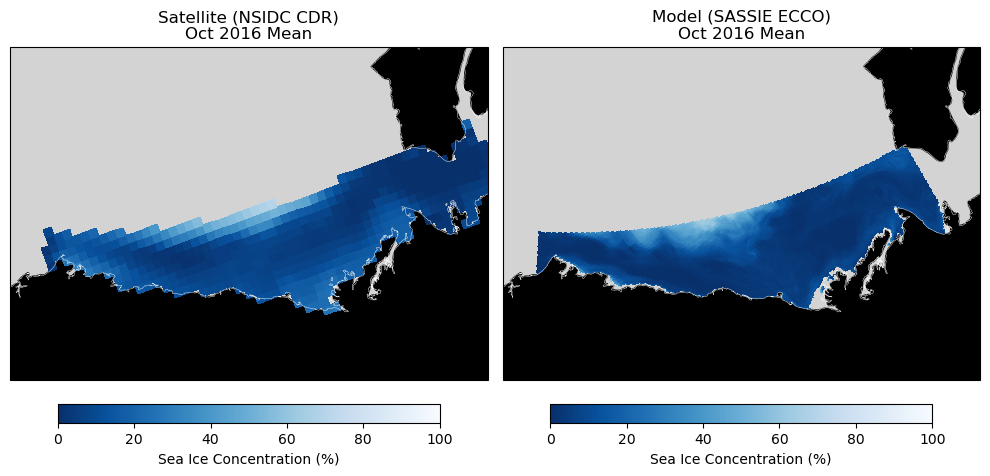

In [23]:
# --- Projection setup ---
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# --- Data setup ---
sic = sat_sic_sept_monthly_mean.copy()
x = sic["x"].values
y = sic["y"].values
xx, yy = np.meshgrid(x, y)
lon, lat = transformer.transform(xx, yy)
sic = sic.assign_coords(lon=(("y", "x"), lon), lat=(("y", "x"), lat))

# --- Figure setup ---
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)

for ax in [ax1, ax2]:
    ax.set_extent([-160, -125, 68, 75], crs=ccrs.PlateCarree())

    # Set background color (ocean/ice) to gray
    ax.set_facecolor("lightgray")

    # Add black land and thin coastlines
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '50m',
        edgecolor='face',
        facecolor='black'
    )
    ax.add_feature(land, zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, color='white')

# --- Plot SIC fields ---
pcm = ax1.pcolormesh(
    sic.lon, sic.lat, sic,
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

pcm1 = ax2.pcolormesh(
    model_sic_sept_monthly.XC,
    model_sic_sept_monthly.YC,
    model_sic_sept_monthly,
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

# --- Colorbars ---
cbar1 = plt.colorbar(pcm, ax=ax1, orientation='horizontal', shrink=0.8, pad=0.05)
cbar1.set_label("Sea Ice Concentration (%)")

cbar2 = plt.colorbar(pcm1, ax=ax2, orientation='horizontal', shrink=0.8, pad=0.05)
cbar2.set_label("Sea Ice Concentration (%)")

# --- Titles ---
ax1.set_title(f"Satellite (NSIDC CDR)\nOct 2016 Mean")
ax2.set_title(f"Model (SASSIE ECCO)\nOct 2016 Mean")

plt.tight_layout()
plt.show()

In [17]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

# apply beaufort mask to grid cell area
# grid_area_beaufort = HH_grid.rAc.where(HH_grid.hFacC.isel(k=0)).where(beaufort_mask).isel(i=slice(510,850),j=slice(0,450))

In [18]:
# select the time range
sic_model_da = sic_beaufort_da.sel(time=slice("2014", "2020"))

In [19]:
# # compute monthly means
# sic_da_monthly = sic_model_da.resample(time="ME", label="right", closed="right").mean()
# sic_da_monthly["time"] = [pd.Timestamp(pd.to_datetime(t)).replace(day=15) for t in sic_da_monthly.time.values]

# # average spatially (over i and j)
# sic_monthly_mean = sic_da_monthly.mean(dim=("i", "j")).load()
# sic_monthly_std = sic_da_monthly.std(dim=("i", "j")).load()

In [20]:
# compute spatial averages first (daily/timestep mean over i,j)
sic_daily_spatial_mean = sic_model_da.mean(dim=("i", "j"), skipna=True)

# then compute monthly mean and std (temporal aggregation)
sic_monthly_stats = sic_daily_spatial_mean.resample(time="ME", label="right", closed="right")

sic_monthly_mean = sic_monthly_stats.mean().compute()
sic_monthly_std = sic_monthly_stats.std(ddof=1).compute()

# assign mid-month timestamps for clarity
sic_monthly_mean["time"] = [pd.Timestamp(pd.to_datetime(t)).replace(day=15) for t in sic_monthly_mean.time.values]
sic_monthly_std["time"]  = sic_monthly_mean["time"]

In [21]:
sic_month_beaufort = (sic_month_tmp.cdr_seaice_conc * 100).where(sat_beaufort_mask)

NameError: name 'sic_month_tmp' is not defined

### Plot both satellite and model data

In [ ]:
# plot mean and std
plt.rcParams['font.size'] = 13
plt.figure(figsize=(10, 3))
plt.plot(sic_monthly_mean.time, sic_monthly_mean, marker='.', label="Model", color="C0")
plt.fill_between(
    sic_monthly_mean.time,
    sic_monthly_mean - sic_monthly_std,
    sic_monthly_mean + sic_monthly_std,
    color="C0",
    alpha=0.3
)

plt.plot(sat_month_ds.time, sat_month_ds.sic_mean, marker='.', label="Satellite", color="k")
plt.fill_between(
    sat_month_ds.time,
    sat_month_ds.sic_mean - sat_month_ds.sic_std,
    sat_month_ds.sic_mean + sat_month_ds.sic_std,
    color="tab:gray",
    alpha=0.3
)

plt.title("Monthly Mean Sea Ice Concentration for Beaufort Sea (2014–2020)")
plt.xlabel("Time")
plt.ylabel("Sea Ice Cover (%)")
plt.ylim(0,100)
plt.xlim(np.datetime64('2014-01-01'),np.datetime64('2020-12-31'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

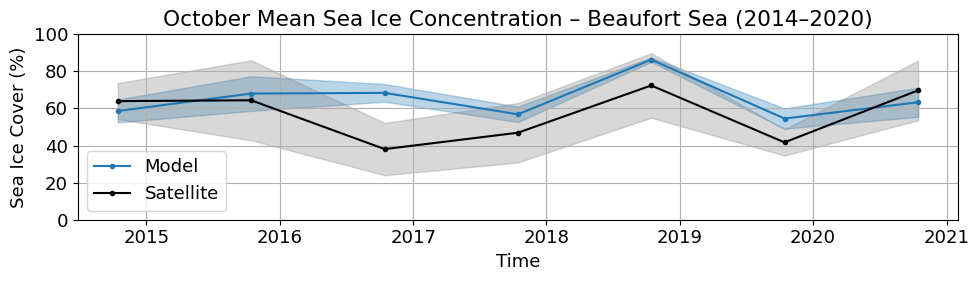

In [37]:
# --- Select October months only ---
sic_oct = sic_monthly_mean.sel(time=sic_monthly_mean.time.dt.month == 10)
sic_oct_std = sic_monthly_std.sel(time=sic_monthly_std.time.dt.month == 10)

sat_oct = sat_month_ds.sel(time=sat_month_ds.time.dt.month == 10)

# --- Plot mean and std for October only ---
plt.rcParams['font.size'] = 13
plt.figure(figsize=(10, 3))

# Model
plt.plot(sic_oct.time, sic_oct, marker='.', label="Model", color="C0")
plt.fill_between(
    sic_oct.time,
    sic_oct - sic_oct_std,
    sic_oct + sic_oct_std,
    color="C0",
    alpha=0.3
)

# Satellite
plt.plot(sat_oct.time, sat_oct.sic_mean, marker='.', label="Satellite", color="k")
plt.fill_between(
    sat_oct.time,
    sat_oct.sic_mean - sat_oct.sic_std,
    sat_oct.sic_mean + sat_oct.sic_std,
    color="tab:gray",
    alpha=0.3
)

plt.title("October Mean Sea Ice Concentration – Beaufort Sea (2014–2020)")
plt.xlabel("Time")
plt.ylabel("Sea Ice Cover (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

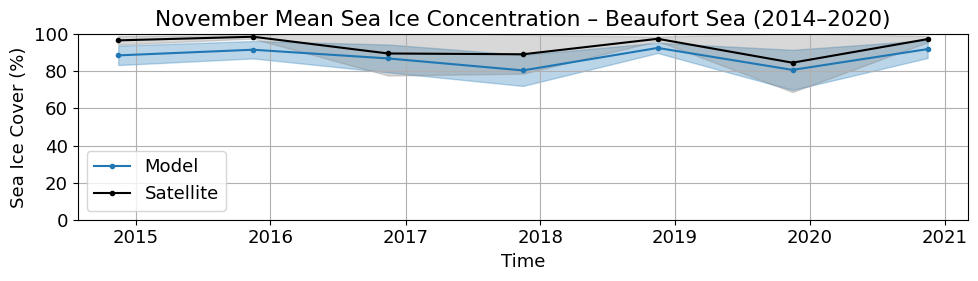

In [38]:
# --- Select October months only ---
sic_oct = sic_monthly_mean.sel(time=sic_monthly_mean.time.dt.month == 11)
sic_oct_std = sic_monthly_std.sel(time=sic_monthly_std.time.dt.month == 11)

sat_oct = sat_month_ds.sel(time=sat_month_ds.time.dt.month == 11)

# --- Plot mean and std for October only ---
plt.rcParams['font.size'] = 13
plt.figure(figsize=(10, 3))

# Model
plt.plot(sic_oct.time, sic_oct, marker='.', label="Model", color="C0")
plt.fill_between(
    sic_oct.time,
    sic_oct - sic_oct_std,
    sic_oct + sic_oct_std,
    color="C0",
    alpha=0.3
)

# Satellite
plt.plot(sat_oct.time, sat_oct.sic_mean, marker='.', label="Satellite", color="k")
plt.fill_between(
    sat_oct.time,
    sat_oct.sic_mean - sat_oct.sic_std,
    sat_oct.sic_mean + sat_oct.sic_std,
    color="tab:gray",
    alpha=0.3
)

plt.title("November Mean Sea Ice Concentration – Beaufort Sea (2014–2020)")
plt.xlabel("Time")
plt.ylabel("Sea Ice Cover (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

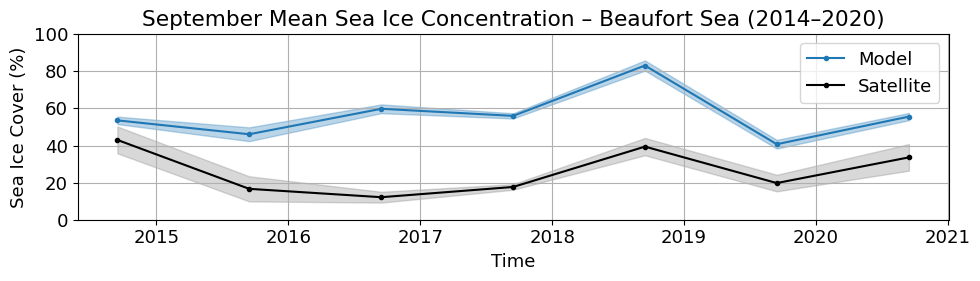

In [39]:
# --- Select October months only ---
sic_oct = sic_monthly_mean.sel(time=sic_monthly_mean.time.dt.month == 9)
sic_oct_std = sic_monthly_std.sel(time=sic_monthly_std.time.dt.month == 9)

sat_oct = sat_month_ds.sel(time=sat_month_ds.time.dt.month == 9)

# --- Plot mean and std for October only ---
plt.rcParams['font.size'] = 13
plt.figure(figsize=(10, 3))

# Model
plt.plot(sic_oct.time, sic_oct, marker='.', label="Model", color="C0")
plt.fill_between(
    sic_oct.time,
    sic_oct - sic_oct_std,
    sic_oct + sic_oct_std,
    color="C0",
    alpha=0.3
)

# Satellite
plt.plot(sat_oct.time, sat_oct.sic_mean, marker='.', label="Satellite", color="k")
plt.fill_between(
    sat_oct.time,
    sat_oct.sic_mean - sat_oct.sic_std,
    sat_oct.sic_mean + sat_oct.sic_std,
    color="tab:gray",
    alpha=0.3
)

plt.title("September Mean Sea Ice Concentration – Beaufort Sea (2014–2020)")
plt.xlabel("Time")
plt.ylabel("Sea Ice Cover (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()